# CLIP (ViT-B/32) Benchmark on FashionMNIST

Benchmarks OpenAI's CLIP model (via `open_clip`) on the FashionMNIST test set:
- Throughput (FPS) and per-image latency
- Peak GPU memory usage
- Zero-shot-style k-NN classification accuracy using CLIP image embeddings

**On Kaggle:** Make sure to turn on a GPU accelerator (Settings → Accelerator → GPU T4 x2 or P100) and turn on Internet access (Settings → Internet → On) before running, since this notebook downloads the FashionMNIST dataset and pretrained CLIP weights.

In [1]:
!pip install -q torch torchvision
!pip install -q open_clip_torch
!pip install -q scikit-learn tqdm matplotlib

ERROR: Could not find a version that satisfies the requirement cuda-bindings==12.9.4; platform_system == "Linux" (from torch) (from versions: none)
ERROR: No matching distribution found for cuda-bindings==12.9.4; platform_system == "Linux"
ERROR: Could not find a version that satisfies the requirement open_clip_torch (from versions: none)
ERROR: No matching distribution found for open_clip_torch


In [4]:
!pip install open_clip_torch -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 21.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 99.6 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires num

In [6]:
import time
import torch
import open_clip
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)

if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [8]:
transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.Grayscale(num_output_channels=3),

    transforms.ToTensor()
])

dataset = datasets.FashionMNIST(

    root="./data",
    train=False,
    download=True,
    transform=transform
)

loader = DataLoader(

    dataset,
    batch_size=32,
    shuffle=False
)

print("Total Images:", len(dataset))

print("Classes:", dataset.classes)

100%|██████████| 26.4M/26.4M [00:01<00:00, 17.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 273kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.08MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 17.2MB/s]

Total Images: 10000
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [9]:
clip_model, _, preprocess = open_clip.create_model_and_transforms(

    'ViT-B-32',
    pretrained='openai'
)

clip_model = clip_model.to(device)

clip_model.eval()

print("CLIP MODEL LOADED")

open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP MODEL LOADED


In [10]:
def benchmark_clip_model(model, loader):

    embeddings = []
    all_labels = []

    total_time = 0
    total_images = 0

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    with torch.no_grad():

        for images, labels in tqdm(loader):

            images = images.to(device)

            start = time.time()

            features = model.encode_image(images)

            end = time.time()

            total_time += (end - start)

            total_images += images.size(0)

            features = features.cpu().numpy()

            embeddings.append(features)

            all_labels.append(labels.numpy())

    embeddings = np.concatenate(embeddings, axis=0)

    all_labels = np.concatenate(all_labels, axis=0)

    fps = total_images / total_time

    latency = total_time / total_images

    if torch.cuda.is_available():

        gpu_memory = (
            torch.cuda.max_memory_allocated() / 1024**3
        )

    else:
        gpu_memory = 0

    return {

        "embeddings": embeddings,
        "labels": all_labels,
        "fps": fps,
        "latency": latency,
        "gpu_memory": gpu_memory
    }

In [11]:
clip_results = benchmark_clip_model(

    clip_model,
    loader
)

100%|██████████| 313/313 [00:31<00:00,  9.94it/s]


In [12]:
X = clip_results["embeddings"]

y = clip_results["labels"]

split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

predictions = knn.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

In [13]:
print("\n========== CLIP FINAL RESULTS ==========")

print("Accuracy      :", round(accuracy * 100, 2), "%")

print("FPS           :", round(clip_results["fps"], 2))

print("Latency       :", round(clip_results["latency"], 5))

print("GPU Memory GB :", round(clip_results["gpu_memory"], 2))


========== CLIP FINAL RESULTS ==========
Accuracy      : 81.9 %
FPS           : 3983.76
Latency       : 0.00025
GPU Memory GB : 0.65


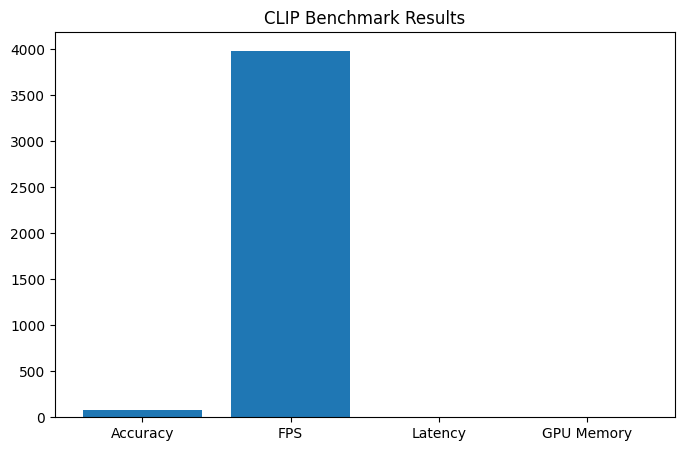

In [14]:
metrics = [

    round(accuracy * 100, 2),

    round(clip_results["fps"], 2),

    round(clip_results["latency"], 5),

    round(clip_results["gpu_memory"], 2)
]

metric_names = [

    "Accuracy",
    "FPS",
    "Latency",
    "GPU Memory"
]

plt.figure(figsize=(8,5))

plt.bar(metric_names, metrics)

plt.title("CLIP Benchmark Results")

plt.show()